In [1]:
from dotenv import load_dotenv
import os


load_dotenv()

True

In [10]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage,AIMessage,HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchRun

from langchain_groq import ChatGroq

from pydantic import BaseModel

In [11]:
# llm
llm=ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

In [15]:
# tools
websearch=DuckDuckGoSearchRun()


def format_report(content: str, title: str = "Report") -> str:
    """Format raw content into a well-structured report with title and sections."""

    report = (
        f"=== {title.upper()} ===\n\n"
        f"SUMMARY\n"
        f"-------\n"
        f"{content}\n\n"
        f"CONCLUSION\n"
        f"----------\n"
        f"This report was compiled by the Writer agent based on research findings."
    )

    return report


In [16]:

research_agent=create_agent(
    model=llm,
    tools=[websearch],
    system_prompt="""
        You are a Research Agent.

        Your task is to research the user's question using the available web search tool.

        Instructions:
        1. Understand the user's research question clearly.
        2. Identify the key information that needs to be researched.
        3. Use the web search tool to find relevant and up-to-date information.
        4. Prefer reliable and authoritative sources.
        5. Compare information from multiple sources when appropriate.
        6. Do not make up facts, sources, statistics, or quotations.
        7. If information is uncertain or conflicting, clearly mention the uncertainty.
        8. Extract the important findings from the search results.
        9. Keep track of the source or URL for each important finding.
        10. Return your findings in a clear format that another agent can use to write the final report.

        Return your research in this structure:

        RESEARCH QUESTION:
        [Original question]

        KEY FINDINGS:
        - Finding 1
        - Finding 2
        - Finding 3

        DETAILED FINDINGS:
        [Detailed explanation of the researched information]

        SOURCES:
        - Source 1: [title + URL]
        - Source 2: [title + URL]
        - Source 3: [title + URL]

        IMPORTANT NOTES:
        [Conflicting information, limitations, uncertainty, or missing information]

        Do not write the final polished report.
        Your job is only to research, verify, and provide evidence for the Writer Agent.
""")

writer_agent=create_agent(
    model=llm,
    tools=[format_report],
    system_prompt="""
You are a Writer Agent responsible for turning research findings into a clear,
accurate, and well-structured final report.

You will receive research findings produced by a Research Agent.

Your responsibilities:

1. Read and understand the research findings carefully.
2. Organize the information into a logical structure.
3. Write a concise but informative report based ONLY on the provided research.
4. Do not invent facts, sources, statistics, quotations, or conclusions.
5. Preserve important details and context from the research.
6. If the research contains conflicting information, clearly mention the conflict.
7. Do not present assumptions or speculation as facts.
8. Use clear, professional language.
9. Remove unnecessary repetition.
10. Make the report easy to read using headings, paragraphs, and bullet points where appropriate.
11. Include relevant sources provided by the Research Agent.
12. Do not perform additional research unless a web-search tool is explicitly available to you.

Before producing the final response, use the `format_report` tool
to format the research findings into a structured report.

The final report should contain:

- A clear title
- Summary
- Main findings
- Important details
- Conclusion
- Sources

Your role is to transform research into a polished report.
Do not change the meaning of the research.
Do not add unsupported information.
"""
)

In [18]:
class AgentState(MessagesState):
    next:str

class RouteDecision(BaseModel):
    next:Literal["researcher","writer","finish"]

In [19]:
SUPERVISOR_SYSTEM_PROMPT = (
    "You are a supervisor managing a team of two specialist agents:\n"
    "\n"
    " - researcher : Finds facts, searches for information, gathers data\n"
    " - writer     : Takes research findings and writes a well-formatted report\n"
    "\n"
    "Given the conversation history, decide which agent should act next.\n"
    "\n"
    "Rules:\n"
    " - If the user request involves finding information, route to 'researcher' first\n"
    " - If research has been done and a report is needed, route to 'writer'\n"
    " - If both research and writing are complete, return 'FINISH'\n"
    " - If the task can be answered without research or writing, return 'FINISH'\n"
    "\n"
    "Respond with ONLY the name of the next agent, or 'FINISH'."
)

In [25]:
supervisor_llm=llm.with_structured_output(RouteDecision)

def supervisor_Node(state:AgentState)->dict:
    message=[SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT)]+state["message"]
    decision:RouteDecision=supervisor_llm.invoke(message)

    print(f"routing to {decision.next}")
    return {"next":decision.next}

In [27]:
def researcher_node(state: AgentState) -> dict:
    """Run the researcher agent and return its response to the shared state."""

    print("  [researcher] working...")

    # Invoke the researcher agent with the current conversation
    result = research_agent.invoke({
        "messages": state["messages"]
    })

    # The agent returns a full messages list; we take the last message (its answer)
    last_message = result["messages"][-1]

    # Wrap it in an AIMessage tagged with the agent's name so we can trace it
    agent_message = AIMessage(
        content=last_message.content,
        name="researcher"
    )

    # Returning {"messages": [...]} causes MessagesState to APPEND (not replace)
    return {"messages":[agent_message]}

In [28]:
def writer_node(state: AgentState) -> dict:
    """Run the researcher agent and return its response to the shared state."""

    print("  [researcher] working...")

    # Invoke the researcher agent with the current conversation
    result = writer_agent.invoke({
        "messages": state["messages"]
    })

    # The agent returns a full messages list; we take the last message (its answer)
    last_message = result["messages"][-1]

    # Wrap it in an AIMessage tagged with the agent's name so we can trace it
    agent_message = AIMessage(
        content=last_message.content,
        name="writer"
    )

    # Returning {"messages": [...]} causes MessagesState to APPEND (not replace)
    return {"messages":[agent_message]}

In [31]:
def route_to_next_node(state:AgentState)->Literal["researcher","writer","__end__"]:
    next_agent=state["next"]

    if next_agent=="finish":
        return END

    else:
        return next_agent

In [36]:
from anyio.functools import S
builder=StateGraph(AgentState)

builder.add_node("supervisor",supervisor_Node)
builder.add_node("researcher",researcher_node)
builder.add_node("writer",writer_node)

builder.add_edge(START,"supervisor")
builder.add_conditional_edges(
    "supervisor",
    route_to_next_node,
    {
        "researcher":"researcher",
        "writer":"writer",
        END:END
    }
)

builder.add_edge("researcher","supervisor")
builder.add_edge("writer","supervisor")

graph=builder.compile()


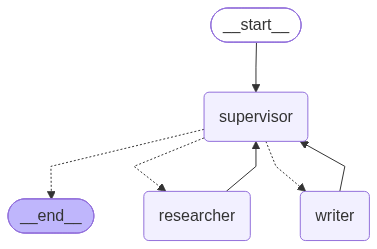

In [37]:
from IPython.display import Image,display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [38]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="Research LangGraph and write a report")
    ]
})

KeyError: 'message'